<h1>A use case in using LanguageChange to study lexical semantic change (diachronic) and variation (synchronic)</h1>
<p>We compare how two novels, Pride and Prejudice (1813) and Little Women (1868), and a multi-genre historical corpus (CCOHA) vary in their representation of a target word.</p>


# 1. Work with the data 

This part explains how we load the data into the LanguageChange library.



## Load Pride and Prejudice and Little Women from text data

We first load the data for Pride and Prejudice and Little Women downloaded from project Gutenberg. These files have already been tokenized and lemmatized.




In [7]:
! python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 3.7 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [8]:
from pathlib import Path

from languagechange.corpora import HistoricalCorpus, LinebyLineCorpus
from languagechange.utils import LiteralTime

target = "agreeable" # Target word we want to investigate
corpus_dir = Path("corpora") # Where our data is located

# Defines the paths to the novel corpora and their corresponding year labels.
novel_paths = [
    corpus_dir / "pp.txt",
    corpus_dir / "lw.txt",
]
novel_year_labels = [
    1813,
    1868,
]

# For each novel corpus, we load the data using our LinebyLineCorpus data loader. 
# We specify that the data is in English, already tokenized and lemmatized.
novel_corpora = []
for p, year in zip(novel_paths, novel_year_labels):
    corpus = LinebyLineCorpus(
        str(p),
        language="en",
        feature="lemma",
        time=LiteralTime(str(year)),
    )
    #corpus = corpus.process(features=["lemma", "token"]) # We process the corpus to extract the lemma and token features.
    novel_corpora.append(corpus)

# We use the HistoricalCorpus class to combine the individual corpora into a single historical corpus. 
# This lets us compare the corpora across time later.
novels = HistoricalCorpus(novel_corpora)
print(novels)

# We can also unpack the individual corpora for easier access.
pp_corpus, lw_corpus = novel_corpora


HistoricalCorpus([<languagechange.corpora.LinebyLineCorpus object at 0x7e8de9a96890>, <languagechange.corpora.LinebyLineCorpus object at 0x7e8ca7d80ed0>], key=<function HistoricalCorpus.<lambda> at 0x7e8cae35efc0>)


## Load COHA data from parquet


Our COHA is in a different data Parquet format. Parquet is a tabular data format, where values are organized by rows and columns. Such a format is more optimal for computers to search through large datasets. 


| Token       | Lemma      | Part-of-speech |
|-------------|------------|----------------|
| The         | the        | DET            |
| unusual     | unusual    | ADJ            |
| mission     | mission    | NOUN           |
| for         | for        | PREP           |
| James       | james      | NOUN           |
| P.          | p.-a       | NOUN           |
| Rubin       | rubin      | NOUN           |
| takes       | take       | VERB           |
| advantage   | advantage  | NOUN           |
| of          | of         | PREP           |
| ties        | tie        | NOUN           |
| he          | he         | PRON           |
| developed   | develop    | VERB           |
| last        | last       | X              |
| year        | year       | NOUN           |
| ...          | ...         | ...           |

In order to load this dataset, we need to use a different loader in the LanguageChange library.

In [9]:
from languagechange.corpora import HistoricalCorpus, ParquetCorpus
from languagechange.utils import LiteralTime

# We load the CCOHA corpora, which are stored in parquet format. 
ccoha_paths = sorted(
    corpus_dir.glob("ccoha_*.parquet"),
    key=lambda p: int(p.stem.split("_")[1]),
)
# Keep track of the year labels for later use.
ccoha_year_labels = [int(p.stem.split("_")[1]) for p in ccoha_paths]

# For each CCOHA corpus, we load the data using our ParquetCorpus data loader.
ccoha_corpora = []
for p, year in zip(ccoha_paths, ccoha_year_labels):
    corpus = ParquetCorpus(
        str(p),
        time=LiteralTime(str(year)),
    )
    ccoha_corpora.append(corpus)

# We combine the individual CCOHA corpora into a single historical corpus, which we can use for analysis.
ccoha = HistoricalCorpus(ccoha_corpora)
print(ccoha)
print(f"Loaded {len(ccoha_corpora)} CCOHA slices: {ccoha_year_labels[0]}-{ccoha_year_labels[-1]}")


HistoricalCorpus([<languagechange.corpora.ParquetCorpus object at 0x7e8caa001d10>, <languagechange.corpora.ParquetCorpus object at 0x7e8caa003050>, <languagechange.corpora.ParquetCorpus object at 0x7e8caa001290>, <languagechange.corpora.ParquetCorpus object at 0x7e8caa002a50>], key=<function HistoricalCorpus.<lambda> at 0x7e8cae35efc0>)
Loaded 4 CCOHA slices: 1880-2000


<p>Keep everything together in one historical corpus spanning all available time points.</p>


In [10]:
from languagechange.corpora import HistoricalCorpus

all_corpora = HistoricalCorpus(novel_corpora + ccoha_corpora)
print(all_corpora)

HistoricalCorpus([<languagechange.corpora.LinebyLineCorpus object at 0x7e8de9a96890>, <languagechange.corpora.LinebyLineCorpus object at 0x7e8ca7d80ed0>, <languagechange.corpora.ParquetCorpus object at 0x7e8caa001d10>, <languagechange.corpora.ParquetCorpus object at 0x7e8caa003050>, <languagechange.corpora.ParquetCorpus object at 0x7e8caa001290>, <languagechange.corpora.ParquetCorpus object at 0x7e8caa002a50>], key=<function HistoricalCorpus.<lambda> at 0x7e8cae35efc0>)


# Step 2: Sample target usages from text data

<p>Search for the target word in the novel corpus collection, the CCOHA collection, and the merged historical corpus. The same lemma-based query is used across both corpus formats.</p>


In [11]:
from languagechange.search import SearchTerm

# We define a search term for the target word we want to investigate. 
# In this case, we search for the lemma "agreeable", which will match all forms of the word (e.g., "agreeable", "agreeably", etc.).
search_term = SearchTerm(lemma=target)
term = str(search_term)
terms = {term}

# We search for the target word across all corpora and print the number of usages found in each corpus.
novel_usages = novels.search(search_term)
ccoha_usages = ccoha.search(search_term)
all_usages = all_corpora.search(search_term)


print(f"Found {len(all_usages[term])} usages of '{target}' across all corpora.")
for year, corpus in zip(ccoha_year_labels, ccoha_corpora):
    year_usages = corpus.search(search_term)
    print(f"CCOHA {year}: {len(year_usages[term])}")


2026-07-02 15:06:05,813 - root - INFO - 33 usages found.
2026-07-02 15:06:06,028 - root - INFO - 13 usages found.
2026-07-02 15:06:06,506 - root - INFO - 67 usages found.
2026-07-02 15:06:07,328 - root - INFO - 80 usages found.
2026-07-02 15:06:07,794 - root - INFO - 19 usages found.
2026-07-02 15:06:08,333 - root - INFO - 8 usages found.
2026-07-02 15:06:08,458 - root - INFO - 33 usages found.
2026-07-02 15:06:08,655 - root - INFO - 13 usages found.
2026-07-02 15:06:09,071 - root - INFO - 67 usages found.
2026-07-02 15:06:09,906 - root - INFO - 80 usages found.
2026-07-02 15:06:10,373 - root - INFO - 19 usages found.
2026-07-02 15:06:10,930 - root - INFO - 8 usages found.


Found 220 usages of 'agreeable' across all corpora.


2026-07-02 15:06:11,367 - root - INFO - 67 usages found.


CCOHA 1880: 67


2026-07-02 15:06:12,160 - root - INFO - 80 usages found.


CCOHA 1920: 80


2026-07-02 15:06:12,632 - root - INFO - 19 usages found.


CCOHA 1960: 19


2026-07-02 15:06:13,141 - root - INFO - 8 usages found.


CCOHA 2000: 8


<p>Sample up to 100 usages per time point for each collection. The CCOHA years are inferred directly from the discovered parquet filenames.</p>

In [12]:
from languagechange.usages import UsageDictionary
from languagechange.utils import LiteralTime

novel_years = [LiteralTime(str(y)) for y in novel_year_labels]
ccoha_years = [LiteralTime(str(y)) for y in ccoha_year_labels]
all_years = [LiteralTime(str(y)) for y in novel_year_labels + ccoha_year_labels]
print(novel_year_labels)
print(ccoha_year_labels)
print(all_years)

novel_usages = UsageDictionary({
    term: novel_usages[term].sample_per_time(times=novel_year_labels, n_samples=100)
    for term in terms
})
ccoha_usages = UsageDictionary({
    term: ccoha_usages[term].sample_per_time(times=ccoha_year_labels, n_samples=100)
    for term in terms
})
all_usages = UsageDictionary({
    term: all_usages[term].sample_per_time(times=novel_year_labels + ccoha_year_labels, n_samples=100)
    for term in terms
})


[1813, 1868]
[1880, 1920, 1960, 2000]
[1813, 1868, 1880, 1920, 1960, 2000]


<p>Optionally save the sampled usages for later reuse.</p>


In [13]:
novel_usages.save("usages/pp_lw_ccoha/novels")
ccoha_usages.save("usages/pp_lw_ccoha/ccoha")
all_usages.save("usages/pp_lw_ccoha/all")

# To load them again:
# novel_usages = UsageDictionary()
# novel_usages.load("usages/pp_lw_ccoha/novels")
# ccoha_usages = UsageDictionary()
# ccoha_usages.load("usages/pp_lw_ccoha/ccoha")
# all_usages = UsageDictionary()
# all_usages.load("usages/pp_lw_ccoha/all")


2026-07-02 15:06:13,457 - root - INFO - Usages written to usages/pp_lw_ccoha/novels/lemma=agreeable_usages.jsonl
2026-07-02 15:06:13,460 - root - INFO - Usages written to usages/pp_lw_ccoha/ccoha/lemma=agreeable_usages.jsonl
2026-07-02 15:06:13,465 - root - INFO - Usages written to usages/pp_lw_ccoha/all/lemma=agreeable_usages.jsonl


<p>Gather usages into two source collections for a direct comparison between the novels and CCOHA.</p>


In [14]:
source_comparison_usages = {
    term: {
        "novels": novel_usages[term],
        "ccoha": ccoha_usages[term],
    }
    for term in terms
}


# Step 3 and 4: Vectorize target usages and compare

<p>Define the contextualized representation model, the clustering algorithm, and the change metric.</p>


In [15]:
import torch
from languagechange.models.change.metrics import JSD
from languagechange.models.representation.contextualized import XL_LEXEME
from sklearn.cluster import AgglomerativeClustering


device = "cuda" if torch.cuda.is_available() else "cpu"

# We initialize the XL-LEXEME model, which is a contextualized embedding model designed for historical language data.
model = XL_LEXEME(device=device)

# We define the clustering algorithm we will use to cluster the contextualized embeddings of the usages.
clustering_algorithm = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=0.5,
    linkage="complete",
    metric="cosine",
)

# We initialize the JSD metric, which is a measure of distributional change 
# that we will use to quantify how much the meaning of the target word has changed over time.
metric = JSD()

2026-07-02 15:06:19,532 - languagechange.models.representation.contextualized - INFO - Initializing XL_LEXEME model.
2026-07-02 15:06:19,538 - WordTransformer.WordTransformer - INFO - Load pretrained SentenceTransformer: pierluigic/xl-lexeme
2026-07-02 15:06:19,818 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/agent-harnesses "HTTP/1.1 200 OK"
2026-07-02 15:06:19,986 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/pierluigic/xl-lexeme/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
2026-07-02 15:06:20,129 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/pierluigic/xl-lexeme/c9f85c6f05b85bc7c5014b5c23846f4467476263/modules.json "HTTP/1.1 200 OK"
2026-07-02 15:06:20,293 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/pierluigic/xl-lexeme/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
2026-07-02 15:06:20,501 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/r

<p>Run the pipeline for the direct comparison between the two source collections.</p>


In [16]:
from languagechange.pipeline import CDPipeline

source_pipeline = CDPipeline(source_comparison_usages, model, metric, clustering_algorithm)
source_sampled_usages, source_embeddings, source_cluster_labels, source_change_scores = source_pipeline.run_pipeline()


2026-07-02 15:06:29,763 - root - INFO - `llama_cpp` is not installed; local prompt models cannot be used.
2026-07-02 15:06:32,339 - matplotlib.font_manager - INFO - Failed to extract font properties from /usr/share/fonts/truetype/noto/NotoColorEmoji.ttf: Non-scalable fonts are not supported
2026-07-02 15:06:32,451 - matplotlib.font_manager - INFO - generated new fontManager
2026-07-02 15:06:32,821 - languagechange.models.representation.contextualized - INFO - Encoding target usages with batch size: 8
Batches: 100%|██████████| 6/6 [00:07<00:00,  1.31s/it]
2026-07-02 15:06:40,720 - languagechange.models.representation.contextualized - INFO - Encoding target usages with batch size: 8
Batches: 100%|██████████| 22/22 [00:59<00:00,  2.72s/it]


# Step 5: Plot the results

In this part we plot clustering results across both text domain (syncronic-ish) and time (diacronic).

## Text domain comparison: CCOHA vs. Pride and Prejudice and Little Women

<p>Visualize the usage embeddings and clusters for the novels-versus-CCOHA comparison.</p>


2026-07-02 15:07:40,749 - root - INFO - Projecting embeddings to two dimensions using t-SNE.
2026-07-02 15:07:41,549 - root - INFO - Done. Reduced embeddings were saved.


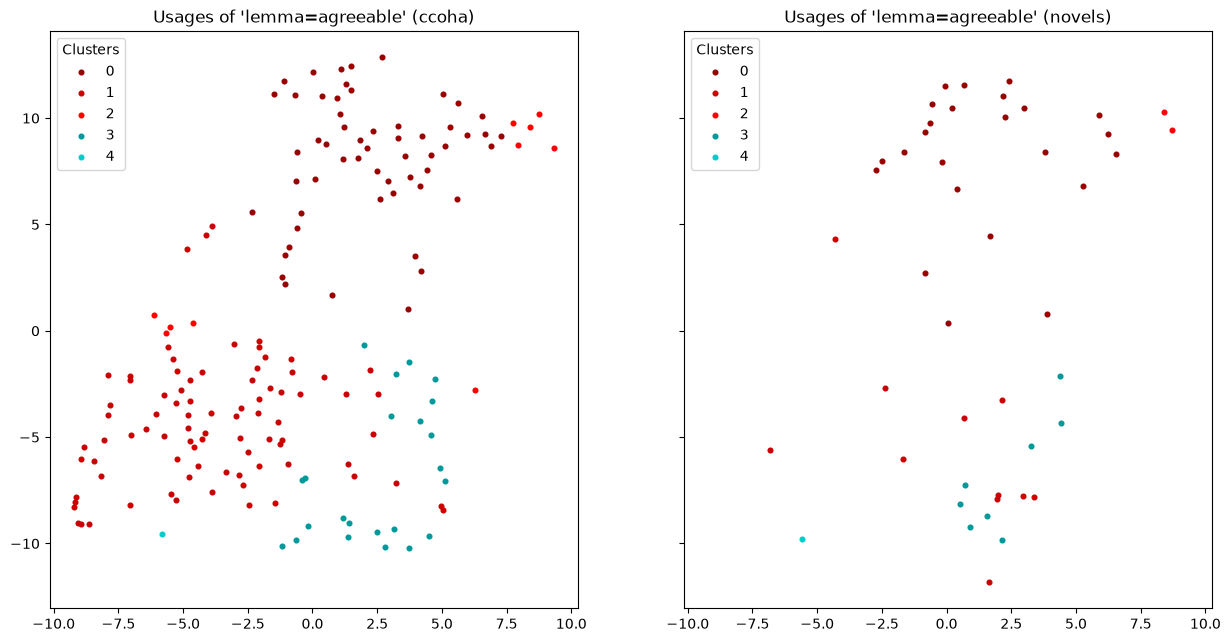

In [17]:
from languagechange.visualization import Visualizer

source_visualizer = Visualizer(
    usages=source_sampled_usages[term],
    embeddings=source_embeddings[term],
    cluster_labels=source_cluster_labels[term],
    target=term,
)

source_visualizer.plot_usage_embeddings()


<p>Inspect example usages from that comparison.</p>

In [18]:
source_visualizer.display_usages(max_usages=10, randomize=True)

Cluster 0:


1920:	Carol was fond of Maud Dyer , because she had been particularly **agreeable** lately ; had obviously repented of the nervous distaste which she had once shown .

1880:	With all this , he proved himself a very **agreeable** companion .

1813:	the most **agreeable** man I ever saw--and if he becomes really attached to

1880:	That very first Sunday , after evening meeting , he induced Fanny Miller , at whose father 's house he boarded , to introduce him to Madeline , and afterward walked home with her , making himself very **agreeable** , and crowning his audacity by asking permission to call .

...

1920:	They had advanced from the new house to **agreeable** general fussing .

--------------------------------------------------------------------------------
Cluster 4:


1813:	"It has been a very **agreeable** day," said Miss Bennet to Elizabeth. "The

1920:	A drowsy river boat in that long **agreeable** northern twilight would finally gather up the family at the dock and drop them off at home .

--------------------------------------------------------------------------------


## Time comparison: Across all time points

We now compare the clustering results by years: Pride and prejudice (1813), Little Women (1868), CCOHA 1880, 1920, 1960, 2000. 

The novels and CCOHA slices as are treated as one historical sequence and runs the pipeline across time.


In [19]:
from languagechange.pipeline import CDPipeline

merged_historical_usages = {
    term: {
        "english_texts": all_usages[term],
    }
    for term in terms
}

historical_pipeline = CDPipeline(merged_historical_usages, model, metric, clustering_algorithm)

years_per_time_period = 1

historical_sampled_usages, historical_embeddings, historical_cluster_labels, historical_change_scores = historical_pipeline.run_pipeline(
    time_period_length=years_per_time_period
)

2026-07-02 15:07:42,370 - languagechange.models.representation.contextualized - INFO - Encoding target usages with batch size: 8
Batches: 100%|██████████| 5/5 [00:03<00:00,  1.35it/s]
2026-07-02 15:07:46,078 - languagechange.models.representation.contextualized - INFO - Encoding target usages with batch size: 8
Batches: 100%|██████████| 2/2 [00:01<00:00,  1.25it/s]
2026-07-02 15:07:47,691 - languagechange.models.representation.contextualized - INFO - Encoding target usages with batch size: 8
Batches: 100%|██████████| 9/9 [00:25<00:00,  2.78s/it]
2026-07-02 15:08:12,747 - languagechange.models.representation.contextualized - INFO - Encoding target usages with batch size: 8
Batches: 100%|██████████| 10/10 [00:23<00:00,  2.39s/it]
2026-07-02 15:08:36,625 - languagechange.models.representation.contextualized - INFO - Encoding target usages with batch size: 8
Batches: 100%|██████████| 3/3 [00:06<00:00,  2.14s/it]
2026-07-02 15:08:43,069 - languagechange.models.representation.contextualized 

<p>Visualize the embeddings across the full historical sequence.</p>


2026-07-02 15:08:45,678 - root - INFO - Projecting embeddings to two dimensions using t-SNE.
2026-07-02 15:08:46,572 - root - INFO - Done. Reduced embeddings were saved.


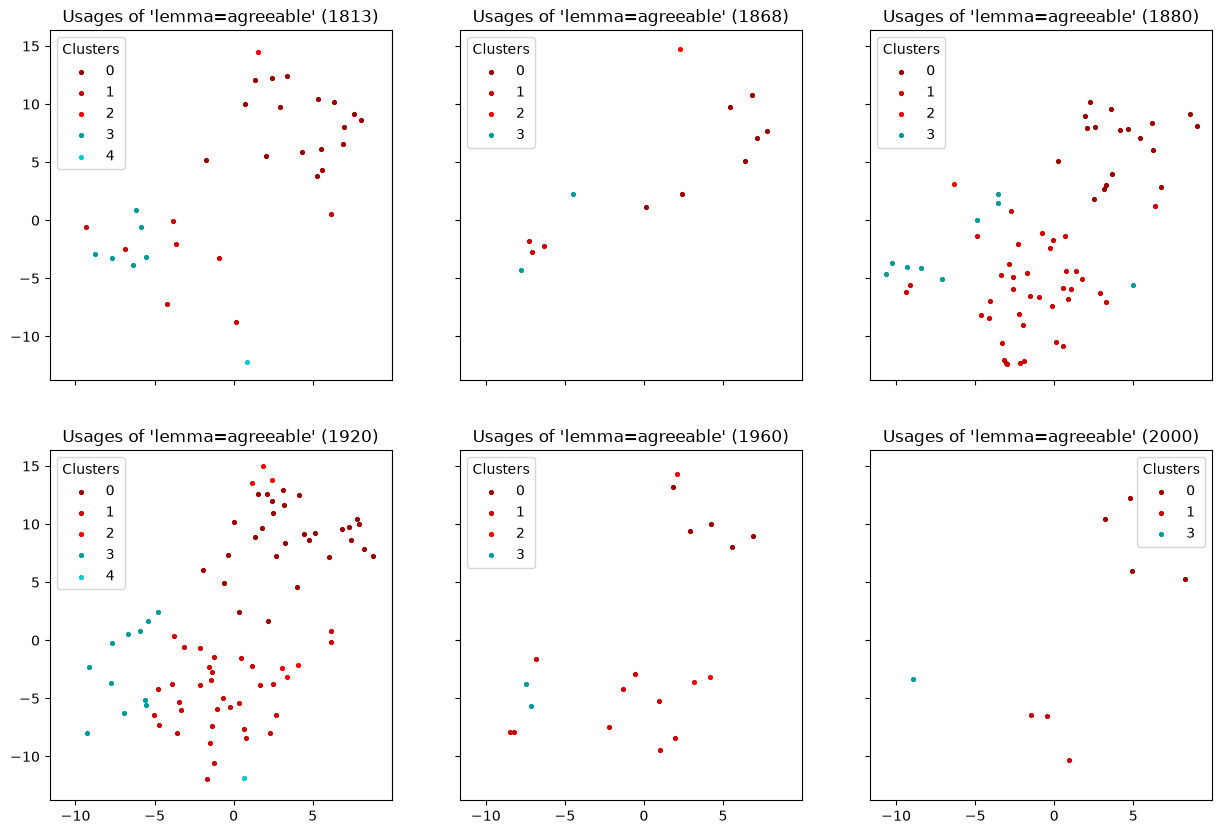

In [20]:
from languagechange.visualization import Visualizer

historical_visualizer = Visualizer(
    usages=historical_sampled_usages[term],
    embeddings=historical_embeddings[term],
    cluster_labels=historical_cluster_labels[term],
    target=term,
)

historical_visualizer.plot_usage_embeddings(target=term)


<p>Inspect example usages from the merged historical corpus.</p>


In [21]:
historical_visualizer.display_usages(max_usages=10, randomize=True)


Cluster 0:


1868:	    and is altogether the most **agreeable** young man I ever

1813:	**agreeable** companion. But on the following morning, every hope of this

1920:	Just as they were about to decide on a course of action , Andrew spoke : " I dinna want ony mair o ' ye than can be helped to get into bother , so , if ye like , Jamie Lauder -- if he 's **agreeable** -- could gang wi ' me and Geordie Sinclair , and we 'll put the

1813:	the most **agreeable** man I ever saw--and if he becomes really attached to

...

1880:	And with this **agreeable** little speech he walked away .

--------------------------------------------------------------------------------
Cluster 4:


1813:	"It has been a very **agreeable** day," said Miss Bennet to Elizabeth. "The

1920:	A drowsy river boat in that long **agreeable** northern twilight would finally gather up the family at the dock and drop them off at home .

--------------------------------------------------------------------------------


## Plot rate of change for each year

<p>Plot the change score time series for the target word across the available time points.</p>


2026-07-02 15:08:47,538 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-02 15:08:47,540 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


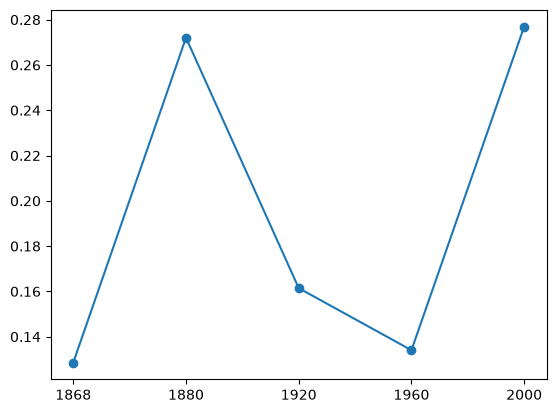

In [22]:
historical_change_scores[term].plot()
